### Generate data

In [35]:
import covasim as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools as it

# The lines below are specific to the notebook format
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

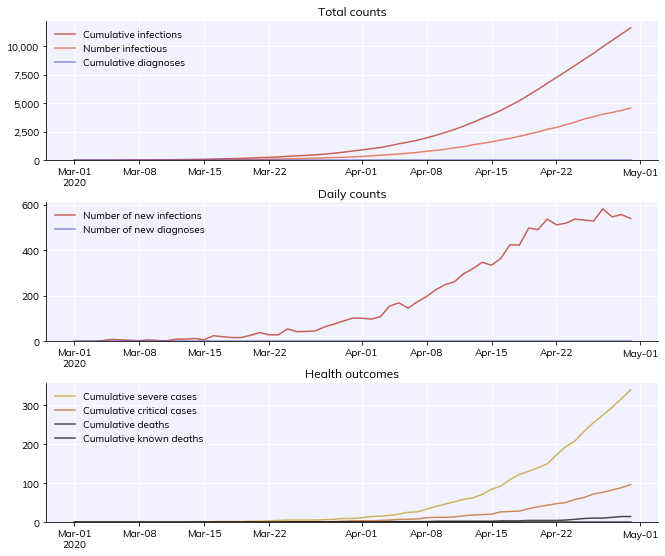

In [36]:
sim = cv.Sim(verbose=0)
sim.run().plot();

## One-dimensional sweep over beta to create `beta_sweep.csv`

In [37]:
betas = np.logspace(-2.25, -1.25, 100)
sims = []
for i, beta in enumerate(betas):
    sim = cv.Sim(beta=beta, rand_seed=i, label=f'Beta = {beta}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days




Initializing sim with 20000 people for 60 days
  Running "Beta = 0.005623413251903491": 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running "Beta = 0.007433821372520386": 2020-03-01 ( 0/60) (0.13 s)  ———————————————————— 2%%
  Running "Beta = 0.006932806692144524": 2020-03-01 ( 0/60) (0.14 s)  ———————————————————— 2%

  Running "Beta = 0.006465558724388368": 2020-03-01 ( 0/60) (0.16 s)  ———————————————————— 2%
  Running "Beta = 0.0091647624407065": 2020-03-01 ( 0/60) (0.14 s)  ———————————————————— 2%18%

  Running "Beta = 0.0060298017058345935": 2020-03-11 (10

MultiSim("Beta = 0.005623413251903491"; n_sims: 100; base: Sim("Beta = 0.005623413251903491"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

,log_beta,cum_inf
0,-2.250000,290.0
1,-2.239899,215.0
2,-2.229798,367.0
3,-2.219697,53.0
4,-2.209596,113.0
...,...,...
95,-1.290404,28676.0
96,-1.280303,29965.0
97,-1.270202,30126.0
98,-1.260101,29989.0


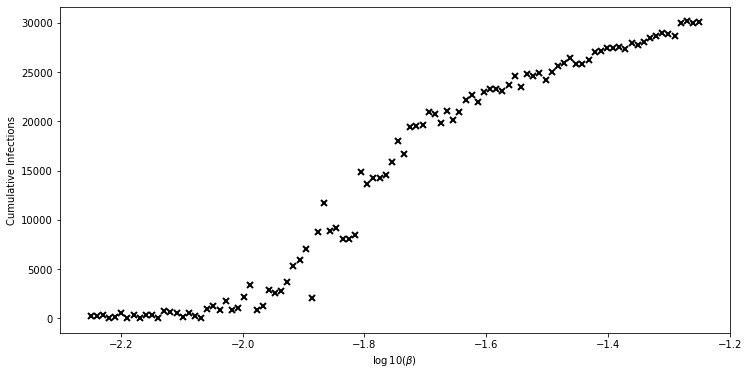

In [38]:
X = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X, 'cum_inf': Y})
display(df)
df.to_csv('sweep_beta.csv')

f, ax = plt.subplots();
ax.plot(X, Y, 'kx', mew=2);
ax.set_xlabel(r'$\log10(\beta$)');
ax.set_ylabel('Cumulative Infections');

## Two dimensional

In [39]:
betas = np.logspace(-2.25, -1.25, 20)
pop_infs = np.linspace(2, 100, 20)

z = list(it.product(betas, pop_infs))

sims = []
for i, (beta, pop_inf) in enumerate(z):
    sim = cv.Sim(beta=beta, pop_infected=pop_inf, rand_seed=i, label=f'Beta = {beta}, Seeds = {pop_inf}')
    sims.append(sim)
msim = cv.MultiSim(sims, reseed=True)
msim.run()

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days

Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 daysInitializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
Initializing sim with 20000 people for 60 days
  Running "Beta = 0.005623413251903491, Seeds = 2.0": 2020-03-01 ( 0/60) (0.09 s)  ———————————————————— 2%
  Running "Beta = 0.00634792195935048, Seeds = 2.0": 2020-03-01 ( 0/60) (0.13 s)  ———————————————————— 2%
  Running "Beta = 0.00634792195935048, Seeds = 53.578947368421055": 2020-03-01 ( 0/60) (0.12 s)  ———————————————————— 2%
  Running "Beta = 0.005623413251903491, Seeds = 2.0": 2020-03-11 (10/60) (0.15 s)  •••————————————————— 18%
  Running "Beta = 0.005623413251903491, Seeds = 53.578947368421055": 2020-03-01 ( 0/60) 

MultiSim("Beta = 0.005623413251903491, Seeds = 2.0"; n_sims: 400; base: Sim("Beta = 0.005623413251903491, Seeds = 2.0"; 2020-03-01 to 2020-04-30; pop: 20000 random; epi: not run))

cum_inf                                                        \
pop_infected      2        7        12       17       22       27       32    
log_beta                                                                      
-2.250000         7.0     85.0    119.0    117.0     73.0    309.0    399.0   
-2.197368        50.0      7.0     65.0    311.0    131.0    238.0    369.0   
-2.144737        15.0     23.0     66.0    299.0     99.0    373.0    474.0   
-2.092105         3.0    209.0    599.0    151.0    873.0   1154.0    571.0   
-2.039474       496.0     21.0   1716.0    653.0   1610.0   1258.0   1569.0   
-1.986842       319.0   1378.0   1230.0   1012.0   1559.0    952.0   2091.0   
-1.934211         3.0    448.0    513.0   1877.0   1082.0   4462.0   2666.0   
-1.881579       718.0   2909.0   1026.0   5387.0   7814.0   4001.0   8770.0   
-1.828947      2486.0  10139.0   5367.0   9156.0  14283.0  14694.0  14196.0   
-1.776316         2.0   6608.0  14754.0  13047.0  13344.0  15632.0  13243.0   
-1.723684      1755.0   4281.0  10616.0  18017.0  18802.0  19045.0  19788.0   
-1.671053      2202.0  14454.0  19853.0  20023.0  20819.0  20297.0  21447.0   
-1.618421     21199.0  20429.0  16994.0  22340.0  21386.0  22858.0  23197.0   
-1.565789     18402.0  22836.0  23343.0  23723.0  23858.0  24029.0  23513.0   
-1.513158     20293.0  22996.0  24627.0  24680.0  24889.0  25270.0  25087.0   
-1.460526     24388.0  22918.0  25194.0  25348.0  26100.0  26339.0  26381.0   
-1.407895     24446.0  26652.0  26468.0  26724.0  26717.0  27190.0  27224.0   
-1.355263      3010.0  27168.0  27860.0  27722.0  27941.0  28350.0  28191.0   
-1.302632     28344.0  28748.0  28962.0  28402.0  29217.0  29498.0  29197.0   
-1.250000     25201.0  29319.0  30281.0  29723.0  29898.0  29844.0  30270.0   

                                                                             \
pop_infected      38       43       48       53       58       63       69    
log_beta                                                                      
-2.250000       210.0    489.0    451.0    327.0    260.0    813.0    499.0   
-2.197368       123.0    288.0    257.0    637.0    430.0    739.0    936.0   
-2.144737       280.0   1496.0   1159.0   1269.0    953.0    632.0   1967.0   
-2.092105       811.0    900.0   2273.0   1344.0   2061.0   1314.0   1406.0   
-2.039474      2130.0   2029.0   1359.0   2550.0   3151.0   2195.0   2513.0   
-1.986842      5171.0   2181.0   3368.0   3095.0   4943.0   6435.0   5737.0   
-1.934211      5416.0   6493.0   6292.0   7906.0   4275.0   8295.0   8082.0   
-1.881579      7856.0  11452.0  10723.0   9828.0  11450.0  11980.0  12627.0   
-1.828947     13568.0  14866.0  14248.0  15336.0  13368.0  15620.0  13054.0   
-1.776316     16631.0  14206.0  17031.0  17699.0  18550.0  17589.0  19455.0   
-1.723684     19270.0  19516.0  20578.0  19781.0  19240.0  20999.0  20584.0   
-1.671053     21740.0  21655.0  22478.0  22207.0  21768.0  21926.0  22446.0   
-1.618421     23328.0  22955.0  23170.0  22468.0  23232.0  23093.0  23527.0   
-1.565789     24433.0  24630.0  24374.0  24324.0  24415.0  24232.0  24474.0   
-1.513158     24934.0  25343.0  25442.0  25567.0  25619.0  25553.0  25538.0   
-1.460526     26307.0  26213.0  26541.0  26678.0  26669.0  26594.0  26628.0   
-1.407895     27301.0  27551.0  27204.0  27533.0  27788.0  27391.0  27619.0   
-1.355263     28515.0  28112.0  28337.0  28203.0  28661.0  28181.0  28647.0   
-1.302632     29539.0  29341.0  29550.0  29435.0  29609.0  29567.0  29303.0   
-1.250000     30879.0  30362.0  30614.0  30837.0  30765.0  30891.0  30455.0   

                                                                    
pop_infected      74       79       84       89       94       100  
log_beta                                                            
-2.250000       481.0    490.0    598.0    774.0    759.0    566.0  
-2.197368       831.0    719.0    896.0    896.0    611.0   1025.0  
-2.144737      1088.0   1516.0   

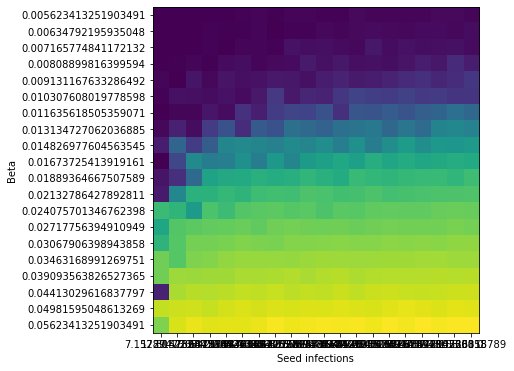

In [40]:
X1 = np.array(np.log10([s.pars['beta'] for s in msim.sims]))
X2 = np.array([s.pars['pop_infected'] for s in msim.sims])
Y = np.array([s.results['cum_infections'][-1] for s in msim.sims])

df = pd.DataFrame({'log_beta': X1, 'pop_infected': X2, 'cum_inf': Y})
df.to_csv('sweep_beta_popinf.csv')

dfp = df.set_index(['log_beta', 'pop_infected']).unstack('pop_infected')
display(dfp)
plt.imshow(dfp)

plt.xlabel('Seed infections');
plt.xticks(ticks=range(len(pop_infs)), labels=pop_infs);

plt.ylabel('Beta')
plt.yticks(ticks=range(len(betas)), labels=betas);